# Le TGIR Huma-num et ses outils


In [1]:
import pandas as pd

import os #pour naviguer dans les dossiers
from io import StringIO
import s3fs #pour connecter au bucket
import scipy.stats

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:


# Create filesystem object
S3_ENDPOINT_URL = "https://" + os.environ["AWS_S3_ENDPOINT"]
fs = s3fs.S3FileSystem(client_kwargs={'endpoint_url': S3_ENDPOINT_URL})

BUCKET_OUT = "aluneau"



In [3]:
with fs.open(f"{BUCKET_OUT}/data_eP8/raw/anonymous_answer_2026-07-24.csv", "r") as file_in:
    df0 = pd.read_csv(file_in, sep =",")

list_affil = pd.read_csv("../list_affiliation.csv", sep =",")
df0 = df0.loc[~df0.q45_clé.isin(["9EAP-NB4B","QNYZ-3MH2"])].merge(list_affil, on = ["q45_clé", "q44_ufr_labo"], how = "left")

In [4]:

df_col = pd.read_csv("../../le_questionnaire/dico_variable.csv", sep = ",")


In [5]:
list_nominal_simple = [x for x in df_col.label.loc[(df_col.type.isin(["simple_nominal", "booléen","ordinal"]))]]


In [6]:
def split_multiple_choices(data, column, index, sep = '|'):
    """
    split and explode column with multiple value

    data = a panda dataframe
    column = name of column which we want to split.
    index = column corresponding to id of rows
    sep = by default '|'. Character use to separate values.
    """
    df_split = data.copy()
    df_split[column]= df_split.apply(lambda row: row[column].replace(";","|") ,1 )
    df_split[column] = df_split[column].str.split(sep)
    df_explode = df_split.explode(column)
    gb_data = df_explode.groupby([column]).agg(nb = (index, "size")).sort_values("nb", ascending=False).reset_index()
    gb_data["total"] = data[index].nunique()
    gb_data["freq"] = gb_data.nb/gb_data.total*100
    gb_data["total_freq"] = gb_data.total/gb_data.total*100
    
    return df_explode, gb_data
    

In [7]:
def grouped_question(data, column, index = "q45_clé"):
    """


    data = a panda dataframe
    column = name of column which we want to split.
    index = column corresponding to id of rows
    sep = by default '|'. Character use to separate values.
    """
    df_tmp = data.copy()
    gb_data = df_tmp.groupby([column]).agg(nb = (index, "size")).reset_index()
    gb_data["total"] = data[index].nunique()
    gb_data["freq"] = gb_data.nb/gb_data.total*100
    gb_data["total_freq"] = gb_data.total/gb_data.total*100

    return gb_data

In [8]:
def tab_croise(data, x, y, regroup_y = True, khideux = False) :
    """
    x = variable en ligne
    y = variable en colonne
    """
    if regroup_y == True:

        data.loc[data[y].str.lower().str.contains("oui"), f"{y}_rec"] = "Oui"
        data.loc[data[y].str.lower().str.contains("non"), f"{y}_rec"] = "Non"

        cross_tab = pd.crosstab(data[x], data[f"{y}_rec"], margins = True, margins_name="Total", normalize=False)
        cross_tab0 = pd.crosstab(data[x], data[f"{y}_rec"], margins = False)
    else:
        cross_tab = pd.crosstab(data[x], data[y], margins = True, margins_name="Total", normalize=False)
        cross_tab0 = pd.crosstab(data[x], data[y], margins = False, normalize=False)

    if khideux == True:
        print(scipy.stats.chi2_contingency(cross_tab0))
        st_chi2, st_p, st_dof, st_exp = scipy.stats.chi2_contingency(cross_tab0)
        chi2 = pd.DataFrame(data={"stats":["chi2","df","p-value"], "values":[st_chi2, st_dof, st_p]})
        cross_tab = pd.concat([cross_tab, chi2])
    else:
        pass

    return cross_tab.fillna("").reset_index(), cross_tab0

In [103]:
g_data = grouped_question(df0, column="q12_humanum", index = "q45_clé")
print(g_data.to_markdown(index=False))

| q12_humanum   |   nb |   total |    freq |   total_freq |
|:--------------|-----:|--------:|--------:|-------------:|
| Non           |   66 |     119 | 55.4622 |          100 |
| Oui           |   53 |     119 | 44.5378 |          100 |


In [21]:
for col in df_col.label.loc[(df_col.label.str.contains("q13_"))&(df_col.type=="booléen")]:
    gb_data= grouped_question(df0, column=col, index="q45_clé")
    print(gb_data.to_markdown())

|    | q13_nakala   |   nb |   total |   freq |   total_freq |
|---:|:-------------|-----:|--------:|-------:|-------------:|
|  0 | Non          |  104 |     119 | 87.395 |          100 |
|  1 | Oui          |   15 |     119 | 12.605 |          100 |
|    | q13_isidore   |   nb |   total |    freq |   total_freq |
|---:|:--------------|-----:|--------:|--------:|-------------:|
|  0 | Non           |   97 |     119 | 81.5126 |          100 |
|  1 | Oui           |   22 |     119 | 18.4874 |          100 |
|    | q13_sharedocs   |   nb |   total |    freq |   total_freq |
|---:|:----------------|-----:|--------:|--------:|-------------:|
|  0 | Non             |   74 |     119 | 62.1849 |          100 |
|  1 | Oui             |   45 |     119 | 37.8151 |          100 |
|    | q13_hébergement_web   |   nb |   total |    freq |   total_freq |
|---:|:----------------------|-----:|--------:|--------:|-------------:|
|  0 | Non                   |  105 |     119 | 88.2353 |          100 |
|

In [23]:
[col for col in df_col.label.loc[(df_col.label.str.contains("q13_"))&(df_col.type=="booléen")]]

['q13_nakala', 'q13_isidore', 'q13_sharedocs', 'q13_hébergement_web']

In [25]:
dict_outil_humanum = {
    'q13_nakala':"Nakala", 
    'q13_isidore':'Isidore',
    'q13_sharedocs':'Sharedocs', 
    'q13_hébergement_web':'Hébergement web'
}

In [35]:
i=-1
for col in df_col.label.loc[(df_col.label.str.contains("q13_"))&(df_col.type=="booléen")]:
    i+=1
    dftmp = df0[["q45_clé", col]].rename(columns={col:"used_tool"})
    dftmp["name_tool"]= dict_outil_humanum[col]


    if i == 0:
        q13 = dftmp.copy()
    else:
        q13 = pd.concat([q13, dftmp])

In [53]:
q13_bis = pd.crosstab(q13.name_tool, q13.used_tool, normalize="index").cumsum(axis=1).stack().reset_index(name='nb')
q13_ter = pd.crosstab(q13.name_tool, q13.used_tool, normalize="index")
q13_ter = q13_ter[['Oui','Non']].cumsum(axis=1).stack().reset_index(name='cum_sum').sort_values(by=["name_tool","used_tool"],ascending=[False, False])
q13_ter

,name_tool,used_tool,cum_sum
6,Sharedocs,Oui,0.378151
7,Sharedocs,Non,1.000000
4,Nakala,Oui,0.126050
5,Nakala,Non,1.000000
2,Isidore,Oui,0.184874
3,Isidore,Non,1.000000
0,Hébergement web,Oui,0.117647
1,Hébergement web,Non,1.000000


In [54]:
q13_ter = q13_ter.merge(q13_bis, on=["name_tool","used_tool"], how = "left")
q13_ter

,name_tool,used_tool,cum_sum,nb
0,Sharedocs,Oui,0.378151,1.000000
1,Sharedocs,Non,1.000000,0.621849
2,Nakala,Oui,0.126050,1.000000
3,Nakala,Non,1.000000,0.873950
4,Isidore,Oui,0.184874,1.000000
5,Isidore,Non,1.000000,0.815126
6,Hébergement web,Oui,0.117647,1.000000
7,Hébergement web,Non,1.000000,0.882353


In [57]:
for x in q13_ter.name_tool.unique():
    non = q13_ter.nb.loc[(q13_ter.name_tool==x) & (q13_ter.used_tool=="Non")]
    q13_ter.loc[q13_ter.name_tool==x, "Oui"] = 1- np.sum(non)
q13_ter = q13_ter.sort_values(["Oui","name_tool","cum_sum"],  ascending=[False, False, False])
q13_ter

,name_tool,used_tool,cum_sum,nb,Oui
1,Sharedocs,Non,1.000000,0.621849,0.378151
0,Sharedocs,Oui,0.378151,1.000000,0.378151
5,Isidore,Non,1.000000,0.815126,0.184874
4,Isidore,Oui,0.184874,1.000000,0.184874
3,Nakala,Non,1.000000,0.873950,0.126050
2,Nakala,Oui,0.126050,1.000000,0.126050
7,Hébergement web,Non,1.000000,0.882353,0.117647
6,Hébergement web,Oui,0.117647,1.000000,0.117647


In [64]:
for col in df_col.label.loc[(df_col.label.str.contains("q14_"))&(df_col.type=="booléen")]:
    gb_data= grouped_question(df0, column=col, index="q45_clé")
    print(gb_data.to_markdown())

|    | q14_stylo   |   nb |   total |     freq |   total_freq |
|---:|:------------|-----:|--------:|---------:|-------------:|
|  0 | Non         |  114 |     119 | 95.7983  |          100 |
|  1 | Oui         |    5 |     119 |  4.20168 |          100 |
|    | q14_mattermost   |   nb |   total |     freq |   total_freq |
|---:|:-----------------|-----:|--------:|---------:|-------------:|
|  0 | Non              |  113 |     119 | 94.958   |          100 |
|  1 | Oui              |    6 |     119 |  5.04202 |          100 |
|    | q14_gitlab   |   nb |   total |    freq |   total_freq |
|---:|:-------------|-----:|--------:|--------:|-------------:|
|  0 | Non          |  103 |     119 | 86.5546 |          100 |
|  1 | Oui          |   16 |     119 | 13.4454 |          100 |
|    | q14_matomo   |   nb |   total |   freq |   total_freq |
|---:|:-------------|-----:|--------:|-------:|-------------:|
|  0 | Non          |  119 |     119 |    100 |          100 |
|    | q14_hnurl   |   

In [65]:
[col for col in df_col.label.loc[(df_col.label.str.contains("q14_"))&(df_col.type=="booléen")]]

['q14_stylo',
 'q14_mattermost',
 'q14_gitlab',
 'q14_matomo',
 'q14_hnurl',
 'q14_kanboard']

In [67]:
dict_outil_humanum2 = {
    'q14_stylo':"Stylo",
 'q14_mattermost':'Mattermost',
 'q14_gitlab':'Gitlab',
 'q14_matomo':'Matomo',
 'q14_hnurl':'Hnurl',
 'q14_kanboard': 'Kanboard'}

In [68]:
i=-1
for col in df_col.label.loc[(df_col.label.str.contains("q14_"))&(df_col.type=="booléen")]:
    i+=1
    dftmp = df0[["q45_clé", col]].rename(columns={col:"used_tool"})
    dftmp["name_tool"]= dict_outil_humanum2[col]


    if i == 0:
        q14= dftmp.copy()
    else:
        q14 = pd.concat([q14, dftmp])

In [69]:
q14_bis = pd.crosstab(q14.name_tool, q14.used_tool, normalize="index").cumsum(axis=1).stack().reset_index(name='nb')
q14_ter = pd.crosstab(q14.name_tool, q14.used_tool, normalize="index")
q14_ter = q14_ter[['Oui','Non']].cumsum(axis=1).stack().reset_index(name='cum_sum').sort_values(by=["name_tool","used_tool"],ascending=[False, False])
q14_ter

,name_tool,used_tool,cum_sum
10,Stylo,Oui,0.042017
11,Stylo,Non,1.000000
8,Mattermost,Oui,0.050420
9,Mattermost,Non,1.000000
6,Matomo,Oui,0.000000
7,Matomo,Non,1.000000
4,Kanboard,Oui,0.042017
5,Kanboard,Non,1.000000
2,Hnurl,Oui,0.025210
3,Hnurl,Non,1.000000


In [70]:
q14_ter = q14_ter.merge(q14_bis, on=["name_tool","used_tool"], how = "left")
q14_ter

,name_tool,used_tool,cum_sum,nb
0,Stylo,Oui,0.042017,1.000000
1,Stylo,Non,1.000000,0.957983
2,Mattermost,Oui,0.050420,1.000000
3,Mattermost,Non,1.000000,0.949580
4,Matomo,Oui,0.000000,1.000000
5,Matomo,Non,1.000000,1.000000
6,Kanboard,Oui,0.042017,1.000000
7,Kanboard,Non,1.000000,0.957983
8,Hnurl,Oui,0.025210,1.000000
9,Hnurl,Non,1.000000,0.974790


In [71]:
for x in q14_ter.name_tool.unique():
    non = q14_ter.nb.loc[(q14_ter.name_tool==x) & (q14_ter.used_tool=="Non")]
    q14_ter.loc[q14_ter.name_tool==x, "Oui"] = 1- np.sum(non)
q14_ter = q14_ter.sort_values(["Oui","name_tool","cum_sum"],  ascending=[False, False, False])
q14_ter

,name_tool,used_tool,cum_sum,nb,Oui
11,Gitlab,Non,1.000000,0.865546,0.134454
10,Gitlab,Oui,0.134454,1.000000,0.134454
3,Mattermost,Non,1.000000,0.949580,0.050420
2,Mattermost,Oui,0.050420,1.000000,0.050420
1,Stylo,Non,1.000000,0.957983,0.042017
0,Stylo,Oui,0.042017,1.000000,0.042017
7,Kanboard,Non,1.000000,0.957983,0.042017
6,Kanboard,Oui,0.042017,1.000000,0.042017
9,Hnurl,Non,1.000000,0.974790,0.025210
8,Hnurl,Oui,0.025210,1.000000,0.025210


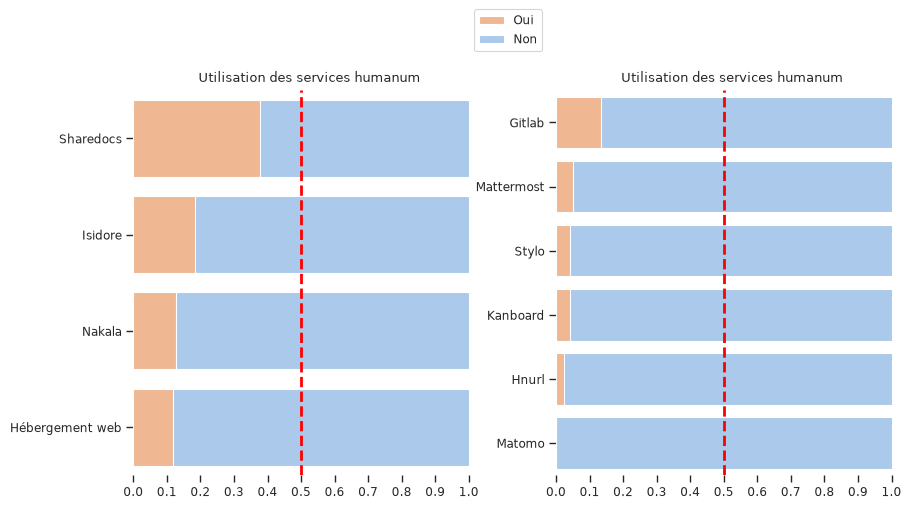

In [95]:
fig, ax = plt.subplots(1,2, figsize=(10,5))

sns.set_theme(style="ticks", context="paper",palette="pastel")


for n, q_data in enumerate([q13_ter, q14_ter]):
    g = sns.barplot(x="cum_sum", y="name_tool", data= q_data, hue="used_tool", dodge = False, ax=ax[n])
        
    titre = f"Utilisation des services humanum"
    
        
    ax[n].yaxis.set_label_text("")
    ax[n].xaxis.set_label_text("")
    ax[n].set_xticks(ticks = [x/10 for x in range(11)])
    ax[n].axvline(x=0.5, color="red", linestyle="--", linewidth=2)
    ax[n].set_title(titre.replace("<i>","(").replace("</i>",")"))
    #ax[n].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)


    sns.despine(left=True, bottom=True)
    ax[n].legend_.remove()

order = [1,0]
handles, labels = ax[0].get_legend_handles_labels()
fig.legend([handles[idx] for idx in order],[labels[idx] for idx in order], loc='center', bbox_to_anchor=(0.5, 1))

plt.savefig(f"./viz/q13_q14_outil_humanum.png", bbox_inches='tight', dpi = 300)

In [82]:
for col in df_col.label.loc[(df_col.label.str.contains("q15_"))&(df_col.type=="booléen")]:
    gb_data= grouped_question(df0, column=col, index="q45_clé")
    print(gb_data.to_markdown())

|    | q15_nakala_help   |   nb |   total |    freq |   total_freq |
|---:|:------------------|-----:|--------:|--------:|-------------:|
|  0 | Non               |   73 |     119 | 61.3445 |          100 |
|  1 | Oui               |   46 |     119 | 38.6555 |          100 |
|    | q15_isidore_help   |   nb |   total |    freq |   total_freq |
|---:|:-------------------|-----:|--------:|--------:|-------------:|
|  0 | Non                |   76 |     119 | 63.8655 |          100 |
|  1 | Oui                |   43 |     119 | 36.1345 |          100 |
|    | q15_sharedocs_help   |   nb |   total |    freq |   total_freq |
|---:|:---------------------|-----:|--------:|--------:|-------------:|
|  0 | Non                  |   76 |     119 | 63.8655 |          100 |
|  1 | Oui                  |   43 |     119 | 36.1345 |          100 |
|    | q15_hébergement_web_help   |   nb |   total |    freq |   total_freq |
|---:|:---------------------------|-----:|--------:|--------:|-------------:|


In [83]:
[col for col in df_col.label.loc[(df_col.label.str.contains("q15_"))&(df_col.type=="booléen")]]

['q15_nakala_help',
 'q15_isidore_help',
 'q15_sharedocs_help',
 'q15_hébergement_web_help',
 'q15_stylo_help',
 'q15_mattermost_help',
 'q15_gitlab_help',
 'q15_matomo_help',
 'q15_hnurl_help',
 'q15_kanboard_help']

In [84]:
dict_outil_humanum2 = {
    'q15_nakala_help':'Nakala',
 'q15_isidore_help':'Isidore',
 'q15_sharedocs_help':'Sharedocs',
 'q15_hébergement_web_help':'Hébergement web',
 'q15_stylo_help':'Stylo',
 'q15_mattermost_help':'Mattermost',
 'q15_gitlab_help':'Gitlab',
 'q15_matomo_help':'Matomo',
 'q15_hnurl_help':'HNurl',
 'q15_kanboard_help':'Kanboard'}

In [85]:
i=-1
for col in df_col.label.loc[(df_col.label.str.contains("q15_"))&(df_col.type=="booléen")]:
    i+=1
    dftmp = df0[["q45_clé", col]].rename(columns={col:"used_tool"})
    dftmp["name_tool"]= dict_outil_humanum2[col]


    if i == 0:
        q15= dftmp.copy()
    else:
        q15 = pd.concat([q15, dftmp])

In [88]:
q15_bis = pd.crosstab(q15.name_tool, q15.used_tool, normalize="index").cumsum(axis=1).stack().reset_index(name='nb')
q15_ter = pd.crosstab(q15.name_tool, q15.used_tool, normalize="index")
q15_ter = q15_ter[['Oui','Non']].cumsum(axis=1).stack().reset_index(name='cum_sum').sort_values(by=["name_tool","used_tool"],ascending=[False, False])
q15_ter

,name_tool,used_tool,cum_sum
18,Stylo,Oui,0.260504
19,Stylo,Non,1.000000
16,Sharedocs,Oui,0.361345
17,Sharedocs,Non,1.000000
14,Nakala,Oui,0.386555
15,Nakala,Non,1.000000
12,Mattermost,Oui,0.218487
13,Mattermost,Non,1.000000
10,Matomo,Oui,0.226891
11,Matomo,Non,1.000000


In [89]:
q15_ter = q15_ter.merge(q15_bis, on=["name_tool","used_tool"], how = "left")


In [90]:
for x in q15_ter.name_tool.unique():
    non = q15_ter.nb.loc[(q15_ter.name_tool==x) & (q15_ter.used_tool=="Non")]
    q15_ter.loc[q15_ter.name_tool==x, "Oui"] = 1- np.sum(non)
q15_ter = q15_ter.sort_values(["Oui","name_tool","cum_sum"],  ascending=[False, False, False])
q15_ter

,name_tool,used_tool,cum_sum,nb,Oui
15,Hébergement web,Non,1.000000,0.605042,0.394958
14,Hébergement web,Oui,0.394958,1.000000,0.394958
5,Nakala,Non,1.000000,0.613445,0.386555
4,Nakala,Oui,0.386555,1.000000,0.386555
3,Sharedocs,Non,1.000000,0.638655,0.361345
2,Sharedocs,Oui,0.361345,1.000000,0.361345
13,Isidore,Non,1.000000,0.638655,0.361345
12,Isidore,Oui,0.361345,1.000000,0.361345
1,Stylo,Non,1.000000,0.739496,0.260504
0,Stylo,Oui,0.260504,1.000000,0.260504


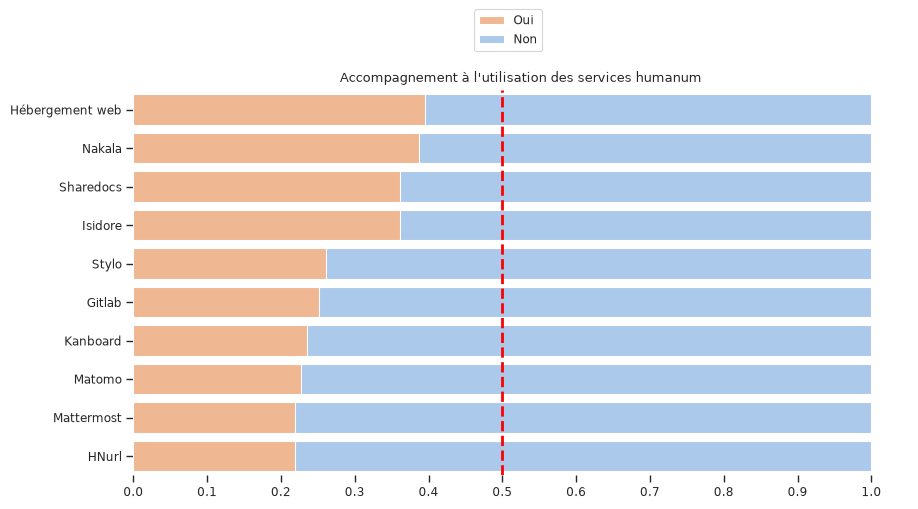

In [97]:
fig, ax = plt.subplots(1, figsize=(10,5))

sns.set_theme(style="ticks", context="paper",palette="pastel")


g = sns.barplot(x="cum_sum", y="name_tool", data= q15_ter, hue="used_tool", dodge = False, ax=ax)
        
titre = f"Accompagnement à l'utilisation des services humanum"

    
ax.yaxis.set_label_text("")
ax.xaxis.set_label_text("")
ax.set_xticks(ticks = [x/10 for x in range(11)])
ax.axvline(x=0.5, color="red", linestyle="--", linewidth=2)
ax.set_title(titre.replace("<i>","(").replace("</i>",")"))
#ax[n].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)


sns.despine(left=True, bottom=True)
ax.legend_.remove()

order = [1,0]
handles, labels = ax.get_legend_handles_labels()
fig.legend([handles[idx] for idx in order],[labels[idx] for idx in order], loc='center', bbox_to_anchor=(0.5, 1))

plt.savefig(f"./viz/q15_help_outil_humanum.png", bbox_inches='tight', dpi = 300)

In [111]:
for col in df_col.label.loc[(df_col.label.str.contains("q13_"))&(df_col.type=="booléen")]:
    print(col)
    print(pd.crosstab(df0.q12_humanum, df0[col], normalize=False, margins=True).to_markdown())

q13_nakala
| q12_humanum   |   Non |   Oui |   All |
|:--------------|------:|------:|------:|
| Non           |    66 |     0 |    66 |
| Oui           |    38 |    15 |    53 |
| All           |   104 |    15 |   119 |
q13_isidore
| q12_humanum   |   Non |   Oui |   All |
|:--------------|------:|------:|------:|
| Non           |    60 |     6 |    66 |
| Oui           |    37 |    16 |    53 |
| All           |    97 |    22 |   119 |
q13_sharedocs
| q12_humanum   |   Non |   Oui |   All |
|:--------------|------:|------:|------:|
| Non           |    56 |    10 |    66 |
| Oui           |    18 |    35 |    53 |
| All           |    74 |    45 |   119 |
q13_hébergement_web
| q12_humanum   |   Non |   Oui |   All |
|:--------------|------:|------:|------:|
| Non           |    63 |     3 |    66 |
| Oui           |    42 |    11 |    53 |
| All           |   105 |    14 |   119 |


La majorité des répondants (55%, {numref}`humanum`) disent ne pas connaître l'infrastructure Huma-Num. Concernant les services, {term}`Sharedocs` est celui qui est le plus ancré dans les usages avec 38% des personnes interrogées qui disent l'avoir déjà utilisé. Viennent ensuit {term}`ISIDORE` (18%),  {term}`Gitlab` (13%) et {term}`Nakala` (13%). Les autres services sont encore plus confidentiels. {term}`Stylo`, un outil de rédaction adapté à l'écriture en sciences sociales, n'a été utilisé que par 4% des répondants. 

```{table} Connaissance de la TGIR Huma-Num
:name: humanum

| q12_humanum   |   nb |    freq |   
|:--------------|-----:|--------:|
| Non           |   66 | 55.5 |          
| Oui           |   53 | 44.5 |         
|Total          |  119 |100.0 |
```



Sur l'ensemble des services Huma-Num, une majorité de répondants ne ressent pas le besoin d'un accompagnement. Les accompagnements les plus demandés portent sur l'hébergement web (39%), Nakala (39%), Sharedocs (36%) et Isidore (36%).

```{figure} ./viz/q13_q14_outil_humanum.png
:name: q13_q14_humanum

L'utilisation des services Huma-Num
```

![](./viz/q15_help_outil_humanum.png)

Le croisement de la question "Connaissez-vous la TGIR Huma-num" et celles sur les outils utilisés montre que ceux-ci ne sont pas toujours associés à Huma-Num. Si toutes les personnes utilisant Nakala connaissent Huma-Num ({numref}`nakala_x_humanum`), ce n'est pas le cas pour ShareDocs ({numref}`sharedocs_x_humanum`) : une dizaine d'utilisateur de ce service ont répondu qu'elles ne connaissez pas la TGIR. On dénombre également 7 personnes connaissant Huma-Num mais n'ayant utilisé aucun des services de l'infrastructure.

```{table} Utilisation de Nakala et connaissance d'Huma-Num
:name: nakala_x_humanum

|    |   Non, je n'ai jamais utilisé Nakal |   Oui, j'ai déjà utilisé Nakala |   Total |
|:--------------|------:|------:|------:|
| Non, je ne connais pas Huma-Num    |    66 |     0 |    66 |
| Oui, je connais Huma-Num           |    38 |    15 |    53 |
| Total          |   104 |    15 |   119 |
```

```{table} Utilisation de ShareDocs et connaissance d'Huma-Num
:name: sharedocs_x_humanum

|    |   Non, je n'ai jamais utilisé ShareDocs |   Oui, j'ai déjà utilisé ShareDocs |   All |
|:--------------|------:|------:|------:|
| Non, je ne connais pas Huma-Num          |    56 |    10 |    66 |
| Oui, je connais Huma-Num          |    18 |    35 |    53 |
| Total           |    74 |    45 |   119 |
```


In [114]:
[col for col in df_col.label.loc[(df_col.label.str.contains("q12_|q13_|q14_"))&(df_col.type=="booléen")]]

['q12_humanum',
 'q13_nakala',
 'q13_isidore',
 'q13_sharedocs',
 'q13_hébergement_web',
 'q14_stylo',
 'q14_mattermost',
 'q14_gitlab',
 'q14_matomo',
 'q14_hnurl',
 'q14_kanboard']

In [125]:
dfb = df0[['q45_clé','q12_humanum',
 'q13_nakala',
 'q13_isidore',
 'q13_sharedocs',
 'q13_hébergement_web',
 'q14_stylo',
 'q14_mattermost',
 'q14_gitlab',
 'q14_matomo',
 'q14_hnurl',
 'q14_kanboard']].replace({"Non": 0, "Oui": 1})

dfb["total"]= dfb.sum(axis=1, numeric_only=True)
dfb.loc[(dfb.q12_humanum==0)&(dfb.total>1)]

/tmp/ipykernel_2973/178739508.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  'q14_kanboard']].replace({"Non": 0, "Oui": 1})


,q45_clé,q12_humanum,q13_nakala,q13_isidore,q13_sharedocs,q13_hébergement_web,q14_stylo,q14_mattermost,q14_gitlab,q14_matomo,q14_hnurl,q14_kanboard,total
3,CV3G-95CT,0,0,0,1,0,0,0,1,0,0,0,2
30,E3YL-PHZV,0,0,1,1,0,0,0,0,0,0,0,2
33,PSFJ-S7YE,0,0,1,1,0,0,0,0,0,0,0,2
72,DT4P-FHKY,0,0,0,0,0,0,1,1,0,0,0,2
99,2QNC-8AAQ,0,0,1,1,0,0,0,0,0,0,0,2
104,A7R6-3SWC,0,0,0,0,0,0,1,1,0,0,0,2
108,X48K-M3K4,0,0,1,1,0,0,0,0,0,0,0,2
